## Group 9 : Marine Heatwave Detection - Seasonal cycle computation

GONNET ARTHUR  
KHATIB MOHAMED-TAIB  
LE SAULNIER LOUIS  
SOUFFAN NATHAN  

### 1st part : Using the python Framework as an example on a single pixel
### 2nd part : Extend the problem to the whole world using big query

**Before starting:**

You need to install Basemap. Do it only once.

In [ ]:
!pip install basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.4/942.4 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 36.1 MB/s eta 0:00:00
  Attempting uninstall: pyproj
    Found existing installation: pyproj 3.7.0
    Uninstalling pyproj-3.7.0:
      Successfully uninstalled pyproj-3.7.0
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


**Import libraries:**

- matplotlib (2D plotting)
- pylab (scientific computing)
- basemap (plotting 2D data on maps)
- scikit-learn (machine learning)
- pandas (data structures and data analysis tools)

In [ ]:
%matplotlib inline
%pylab inline
from mpl_toolkits.basemap import Basemap
import sklearn
import pandas as pd
from scipy.stats.mstats import zscore
import warnings
warnings.filterwarnings("ignore") # disable warnings
pylab.rcParams['figure.figsize']=(20,20) # graph size

Populating the interactive namespace from numpy and matplotlib


**Marine Heat Waves package:**

We load the Marine Heat Waves package of Hobday et al. (2016), which need as inputs a SST time series and a time time series of same length.

In [ ]:
# Load marineHeatWaves definition module (It is necessary to upload the file marineHeatWaves.py to load it on Colab)
import marineHeatWaves as mhw

# and needed libraries
import numpy as np
import scipy as sp
from scipy import linalg
from scipy import stats
import scipy.ndimage as ndimage
from datetime import date

from google.colab import auth**Connection to the GCP:**

First, we have to connect to the Google Cloud Platform. using the following command. Enter the login "bigdataocean2020@gmail.com" and password "bdoimt2022". Do it only once.

In [ ]:
import os
os.environ['USE_AUTH_EPHEM'] = '0'

from google.colab import auth
auth.authenticate_user()

## **Marine Heat Waves Study: example on the Thyrrenian sea**

Start by recovering the SST time series of the Thyrrenian sea, in longitude 9.125 and latitude 38.125.

In [ ]:
%%bigquery output --project alert-ground-261008
SELECT time, sst AS sst_mean
FROM bdo2020.bdo2020.1998_2015
WHERE lon=9.125 AND lat=38.125
ORDER BY time

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
output

,time,sst_mean
0,729390.0,16.20
1,729391.0,16.20
2,729392.0,16.50
3,729393.0,16.65
4,729394.0,16.80
...,...,...
6569,735959.0,16.95
6570,735960.0,16.65
6571,735961.0,16.50
6572,735962.0,16.65


## Marine Heatwave Detection

The marineHeatWaves (`mhw`) module consists of a number of functions for the detection and characterization of MHWs. The main function is the detection function (`detect`) which takes as input a time series of temperature (and a corresponding time vector) and outputs a set of detected MHWs. We first run the MHW detection algorithm which returns the variable `mhws`, consisting of the detected MHWs, and `clim`, consisting of the climatological (varying by day-of-year) seasonal cycle and extremes threshold:


In [ ]:
t=np.asarray(output.time.astype(int)) # The time array ordered by time
sst=np.asarray(output.sst_mean) # The mean SST of Thyrrenian sea array ordered by time

mhws, clim = mhw.detect(t, sst)

This algorithm has detected the following number of MHW events:

In [ ]:
mhws['n_events']

41

In [ ]:
clim

{'thresh': array([17.13145161, 17.07483871, 17.01822581, ..., 17.31048387,
        17.24758065, 17.18951613]),
 'seas': array([16.22625056, 16.1823356 , 16.13959367, ..., 16.36713521,
        16.31857705, 16.27168066]),
 'missing': array([False, False, False, ..., False, False, False])}

In [ ]:
mhws

df_mhws = pd.DataFrame(mhws)

df_mhws


,time_start,time_end,time_peak,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,...,intensity_var_relThresh,intensity_cumulative_relThresh,intensity_max_abs,intensity_mean_abs,intensity_var_abs,intensity_cumulative_abs,category,rate_onset,rate_decline,n_events
0,729397,729410,729401,1998-01-08,1998-01-21,1998-01-12,7,20,11,14,...,0.308306,7.057742,17.55,17.003571,0.391181,238.05,Strong,0.221756,0.105306,41
1,729423,729454,729435,1998-02-03,1998-03-06,1998-02-15,33,64,45,32,...,0.183419,9.637258,16.50,16.134375,0.194630,516.30,Moderate,0.057777,0.028171,41
2,730021,730026,730025,1999-09-24,1999-09-29,1999-09-28,631,636,635,6,...,0.073844,0.915000,25.65,25.650000,0.150000,153.90,Moderate,0.060329,0.222776,41
3,730192,730200,730193,2000-03-13,2000-03-21,2000-03-14,802,810,803,9,...,0.131695,1.592903,16.50,16.333333,0.110554,147.00,Moderate,0.231224,0.062388,41
4,730255,730263,730256,2000-05-15,2000-05-23,2000-05-16,865,873,866,9,...,0.288094,3.548226,20.70,20.583333,0.094281,185.25,Moderate,0.408635,0.097646,41
5,730480,730489,730486,2000-12-26,2001-01-04,2001-01-01,1090,1099,1096,10,...,0.388894,5.486129,18.60,17.775000,0.323458,177.75,Strong,0.234608,0.428914,41
6,730509,730513,730512,2001-01-24,2001-01-28,2001-01-27,1119,1123,1122,5,...,0.203442,1.611290,16.80,16.500000,0.212132,82.50,Moderate,0.149647,0.427761,41
7,730570,730575,730571,2001-03-26,2001-03-31,2001-03-27,1180,1185,1181,6,...,0.046763,0.493065,16.50,16.475000,0.055902,98.85,Moderate,0.119835,0.048319,41
8,730772,730796,730782,2001-10-14,2001-11-07,2001-10-24,1382,1406,1392,25,...,0.187317,11.250000,24.30,23.622000,0.684263,590.55,Moderate,0.102166,0.058576,41
9,730808,730812,730811,2001-11-19,2001-11-23,2001-11-22,1418,1422,1421,5,...,0.179736,1.350968,21.00,20.850000,0.232379,104.25,Moderate,0.190591,0.499137,41


Let's have a look at some properties of the event with the largest maximum intensity

In [ ]:
ev = np.argmax(mhws['intensity_max']) # Find the event with maximum intensity
print('Maximum intensity:', mhws['intensity_max'][ev], 'deg. C')
print('Average intensity:', mhws['intensity_mean'][ev], 'deg. C')
print('Cumulative intensity:', mhws['intensity_cumulative'][ev], 'deg. C-days')
print('Duration:', mhws['duration'][ev], 'days')
print('Start date:', mhws['date_start'][ev].strftime("%d %B %Y"))
print('End date:', mhws['date_end'][ev].strftime("%d %B %Y"))

Maximum intensity: 3.589907135874874 deg. C
Average intensity: 3.0445636719097124 deg. C
Cumulative intensity: 66.98040078201367 deg. C-days
Duration: 22 days
Start date: 09 July 2003
End date: 30 July 2003


and a closer look at the identified MHW event:

Text(0, 0.5, 'SST [$^\\circ$C]')

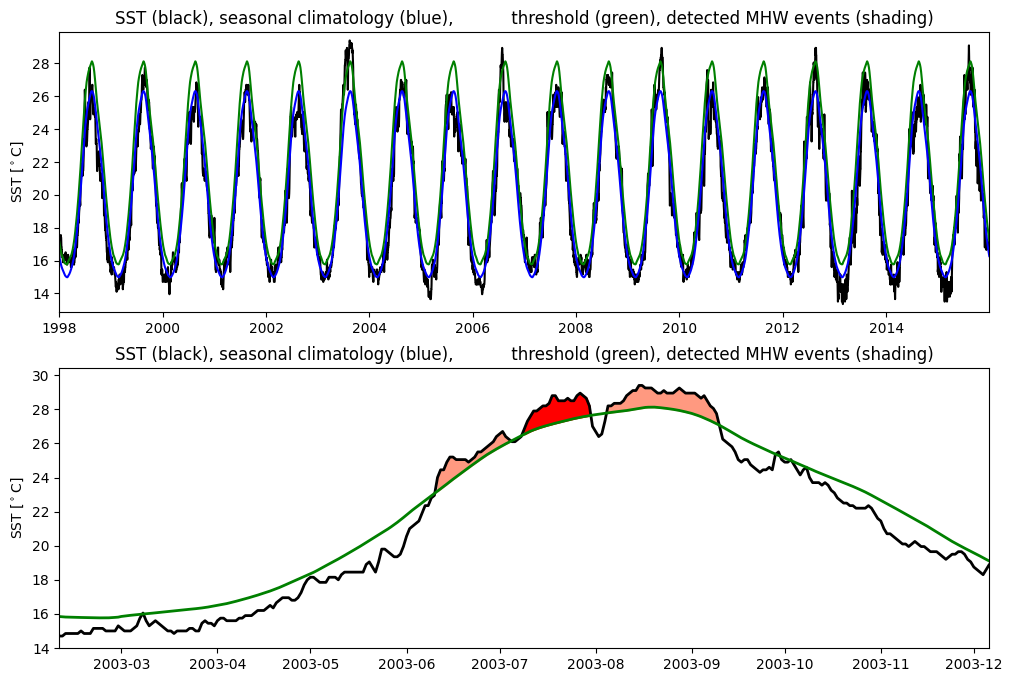

In [ ]:
dates = [date.fromordinal(tt.astype(int)) for tt in t]

delta = clim['thresh'] - clim['seas']

plt.figure(figsize=(12,8))
plt.subplot(2,1,1)
# Plot SST, seasonal cycle, and threshold
plt.plot(dates, sst, 'k-')
plt.plot(dates, clim['thresh'], 'g-')
plt.plot(dates, clim['seas'], 'b-')
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(dates[0], dates[-1])
plt.ylim(sst.min()-0.5, sst.max()+0.5)
plt.ylabel(r'SST [$^\circ$C]')
plt.subplot(2,1,2)
# Find indices for all ten MHWs before and after event of interest and shade accordingly
for ev0 in np.arange(ev-10, ev+11, 1):
    t1 = np.where(t==mhws['time_start'][ev0])[0][0]
    t2 = np.where(t==mhws['time_end'][ev0])[0][0]
    plt.fill_between(dates[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                     color=(1,0.6,0.5))
# Find indices for MHW of interest and shade accordingly
t1 = np.where(t==mhws['time_start'][ev])[0][0]
t2 = np.where(t==mhws['time_end'][ev])[0][0]
plt.fill_between(dates[t1:t2+1], sst[t1:t2+1], clim['thresh'][t1:t2+1], \
                 color='r')
# Plot SST, seasonal cycle, threshold, shade MHWs with main event in red
plt.plot(dates, sst, 'k-', linewidth=2)
plt.plot(dates, clim['thresh'], 'g-', linewidth=2)
plt.plot(dates, clim['seas'], 'b-', linewidth=2)
plt.title('SST (black), seasonal climatology (blue), \
          threshold (green), detected MHW events (shading)')
plt.xlim(date.fromordinal((mhws['time_start'][ev]-150).astype(int)), date.fromordinal((mhws['time_start'][ev]+150).astype(int)))
plt.ylim(clim['seas'].min() - 1, clim['seas'].max() + mhws['intensity_max'][ev] + 0.5)
plt.ylabel(r'SST [$^\circ$C]')

This event with maximum intensity (dark red shading) also seems to have been preceded and succeeded by a number of shorter, weaker events (light red shading). Let's have a look at how the MHW statistics are distributed across all the detected events:

Text(0.5, 0, 'MHW event number')

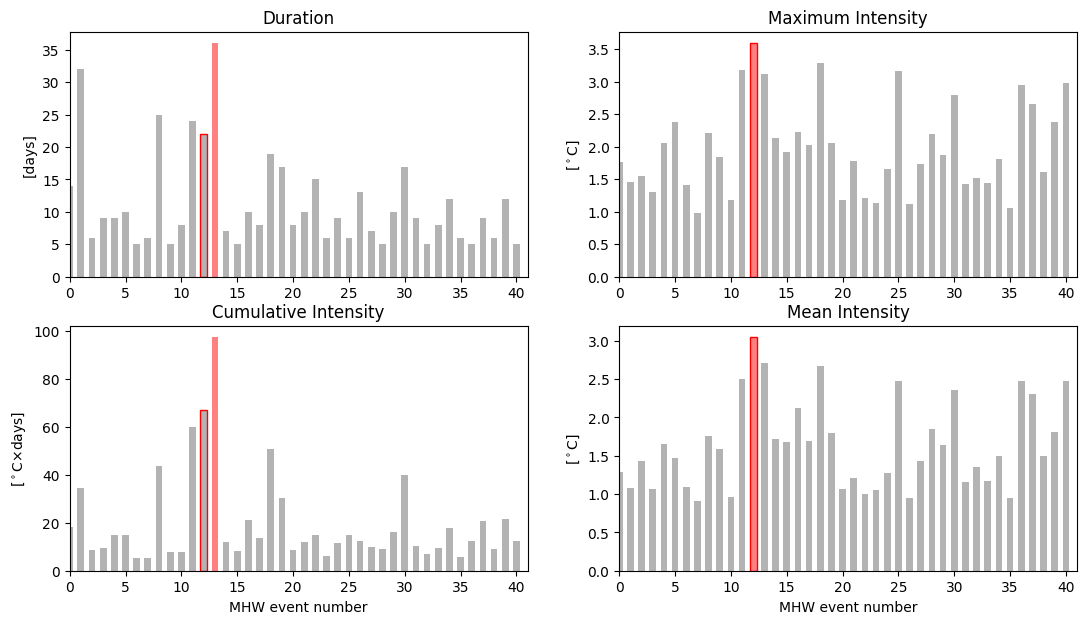

In [ ]:
plt.figure(figsize=(13,7))
# Duration
plt.subplot(2,2,1)
evMax = np.argmax(mhws['duration'])
plt.bar(range(mhws['n_events']), mhws['duration'], width=0.6, \
        color=(0.7,0.7,0.7))
plt.bar(evMax, mhws['duration'][evMax], width=0.6, color=(1,0.5,0.5))
plt.bar(ev, mhws['duration'][ev], width=0.6, edgecolor=(1,0.,0.), \
        color='none')
plt.xlim(0, mhws['n_events'])
plt.ylabel('[days]')
plt.title('Duration')
# Maximum intensity
plt.subplot(2,2,2)
evMax = np.argmax(mhws['intensity_max'])
plt.bar(range(mhws['n_events']), mhws['intensity_max'], width=0.6, \
        color=(0.7,0.7,0.7))
plt.bar(evMax, mhws['intensity_max'][evMax], width=0.6, color=(1,0.5,0.5))
plt.bar(ev, mhws['intensity_max'][ev], width=0.6, edgecolor=(1,0.,0.), \
        color='none')
plt.xlim(0, mhws['n_events'])
plt.ylabel(r'[$^\circ$C]')
plt.title('Maximum Intensity')
# Mean intensity
plt.subplot(2,2,4)
evMax = np.argmax(mhws['intensity_mean'])
plt.bar(range(mhws['n_events']), mhws['intensity_mean'], width=0.6, \
        color=(0.7,0.7,0.7))
plt.bar(evMax, mhws['intensity_mean'][evMax], width=0.6, color=(1,0.5,0.5))
plt.bar(ev, mhws['intensity_mean'][ev], width=0.6, edgecolor=(1,0.,0.), \
        color='none')
plt.xlim(0, mhws['n_events'])
plt.title('Mean Intensity')
plt.ylabel(r'[$^\circ$C]')
plt.xlabel('MHW event number')
# Cumulative intensity
plt.subplot(2,2,3)
evMax = np.argmax(mhws['intensity_cumulative'])
plt.bar(range(mhws['n_events']), mhws['intensity_cumulative'], width=0.6, \
        color=(0.7,0.7,0.7))
plt.bar(evMax, mhws['intensity_cumulative'][evMax], width=0.6, color=(1,0.5,0.5))
plt.bar(ev, mhws['intensity_cumulative'][ev], width=0.6, edgecolor=(1,0.,0.), \
        color='none')
plt.xlim(0, mhws['n_events'])
plt.title(r'Cumulative Intensity')
plt.ylabel(r'[$^\circ$C$\times$days]')
plt.xlabel('MHW event number')

The red shaded bars show the largest event on record by duration, maximum intensity, cumulative intensity, and mean intensity, while the red-outlined bars show the specific event chosen above (which happens to be largest by maximum intensity). We can see how this event ranks according to the other metrics as follows:

In [ ]:
rank, returnPeriod = mhw.rank(t, mhws)
print("The 2012 NWA event is ranked number " \
        + str(rank['duration'][ev]) + " by duration")
print("The 2012 NWA event is ranked number " \
        + str(rank['intensity_max'][ev]) + " by maximum intensity")
print("The 2012 NWA event is ranked number " \
        + str(rank['intensity_mean'][ev]) + " by mean intensity")
print("The 2012 NWA event is ranked number " \
        + str(rank['intensity_cumulative'][ev]) + " by cumulative intensity")

The 2012 NWA event is ranked number 5 by duration
The 2012 NWA event is ranked number 1 by maximum intensity
The 2012 NWA event is ranked number 5 by mean intensity
The 2012 NWA event is ranked number 2 by cumulative intensity


We can even look at the return periods for events with those properties:

In [ ]:
print("The return period for an event with this duration was " \
        + str(returnPeriod['duration'][ev]) + " years")
print("The return period for an event with this maximum intensity was " \
        + str(returnPeriod['intensity_max'][ev]) + " years")
print("The return period for an event with this mean intensity was " \
        + str(returnPeriod['intensity_mean'][ev]) + " years")
print("The return period for an event with this cumulative intensity was " \
        + str(returnPeriod['intensity_cumulative'][ev]) + " years")

The return period for an event with this duration was 3.7997262149212867 years
The return period for an event with this maximum intensity was 18.998631074606433 years
The return period for an event with this mean intensity was 3.7997262149212867 years
The return period for an event with this cumulative intensity was 9.499315537303216 years


## Block-averaged Marine Heatwave properties

The marineHeatWaves (`mhw`) module also consists of functions to calculate the average of MHW properties over blocks in time (e.g., annually, decadally). The block-averaging function (`blockAverage`) takes as input a set of detected MHWs (i.e., the output from `detect`, the detection function described above) and outputs the MHW properties averaged over the specified block-length. This output can then be passed through the `meanTrend` function in order to calculate the time-mean and linear trend of the MHW properties over the measurement period.

Let's start by applying the block-averaging function to the Mediterranean MHWs which are stored in the variable `mhws`, using the default block length of 1 year (i.e., annual averages):

In [ ]:
mhwBlock = mhw.blockAverage(t, mhws)

The variable `mhwBlock` has a set of keys which are time series of the MHW properties over the blocks. The central year of the blocks are stored in the key `years_centre` so we can look at, as an example, time series of MHW counts in each year and the average maximum intensity in each year:


Text(0.5, 1.0, 'Average MHW maximum intensity by year')

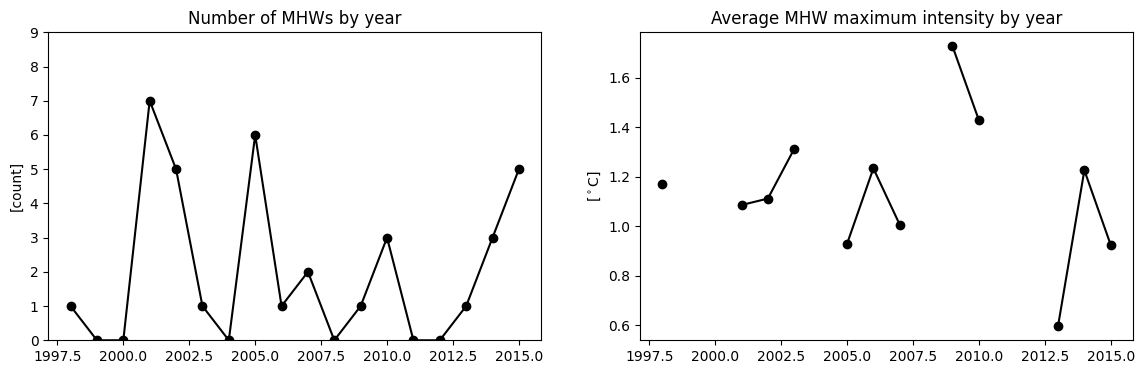

In [ ]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.plot(mhwBlock['years_centre'], mhwBlock['count'], 'k-o')
plt.ylim(0,9)
plt.ylabel('[count]')
plt.title('Number of MHWs by year')
plt.subplot(1,2,2)
plt.plot(mhwBlock['years_centre'], mhwBlock['intensity_max'], 'k-o')
plt.ylabel(r'[$^\circ$C]')
plt.title('Average MHW maximum intensity by year')

We can calculate the mean and trend of the MHW properties using the `meanTrend` function:

In [ ]:
mean, trend, dtrend = mhw.meanTrend(mhwBlock)
print("There are on average " + str(mean['count']) + " MHWs in each year, \n \
with a linear trend of " + str(10*trend['count']) + " MHW events per decade \n \
This trend is statistically significant (p<0.05): " \
+ str(np.abs(trend['count']) > dtrend['count']) + "\n")

print("The average maximum intensity is " + str(mean['intensity_max']) + " deg. C, \n \
with a linear trend of " + str(10*trend['intensity_max']) + " deg. C per decade \n \
This trend is statistically significant (p<0.05): " \
+ str(np.abs(trend['intensity_max']) > dtrend['intensity_max']))

There are on average 1.9999999999999996 MHWs in each year, 
 with a linear trend of 0.06191950464396286 MHW events per decade 
 This trend is statistically significant (p<0.05): False

The average maximum intensity is 1.1486870723197404 deg. C, 
 with a linear trend of -0.07706831152956495 deg. C per decade 
 This trend is statistically significant (p<0.05): False


## **Statistical study of the temporal and spatial evolution of Marine Heat Waves at a planetary scale**

This was an example for a pixel in the Mediterranean sea. However now we want to do the same on the whole planet. The issue is that the python framework would be too slow and won't work on the whole dataset. That's why we want to do the same as the framework but with big query code.

### Big Query code to detect the marine heatwaves all around the world from 2002 to 2015

In [ ]:
%%bigquery marine_heatwaves --project alert-ground-261008

WITH nb_days_seasonal_cycle AS (
-- cette partie permettait de construire notre cycle saisonnier sur la moitié des jours du dataset. Elle n'est plus utile car les fluctuations de notre seuil étaient trop grandes
  SELECT ROUND((MAX(time) + MIN(time))/2, 0) AS end_sc
  FROM bdo2020.bdo2020.1998_2015_withtimes

),


seasonal_cycle AS (

  SELECT
    #AVG(sst) AS mean_sst,
    lon,
    lat,
    day,
    month,
    APPROX_QUANTILES(sst, 100)[OFFSET(90)] AS tsh
  FROM bdo2020.bdo2020.1998_2015_withtimes
  JOIN nb_days_seasonal_cycle ON 1=1
  #WHERE time < end_sc
  WHERE (lat>-39.130 AND lat <39.400)
  AND year>2002 -- explained in the following cell
  GROUP BY lon, lat, day, month
  ORDER BY lon, lat, month, day
),

base_data AS (

  SELECT
  CAST(data.lat AS STRING) AS lat_str,
    CAST(data.lon AS STRING) AS lon_str,
  data.day,
  data.month,
  data.year,
  data.sst,
  data.time,
  tsh,

  CASE
    WHEN sst > tsh
      THEN 1
      ELSE 0
  END AS above_tsh

  FROM bdo2020.bdo2020.1998_2015_withtimes AS data
  LEFT JOIN seasonal_cycle
  ON data.lon = seasonal_cycle.lon
  AND data.lat = seasonal_cycle.lat
  AND data.month = seasonal_cycle.month
  AND data.day = seasonal_cycle.day
  WHERE (data.lat>-39.130 AND data.lat <39.400)
  AND data.year>2002
  ORDER BY data.lon, data.lat, data.time

),

grouped_data AS (
  SELECT
    *,
    -- Identify the groups based on lat, lon, and interruptions in above_threshold
    SUM(CASE WHEN above_tsh = 0 THEN 1 ELSE 0 END)
    OVER (PARTITION BY lat_str, lon_str ORDER BY year, month, day) AS group_id
  FROM
    base_data
),
filtered_groups AS (
  SELECT
    lat_str,
    lon_str,
    group_id,
    COUNT(*) AS group_size,
    MIN(DATE(year, month, day)) AS start_date,
    MAX(DATE(year, month, day)) AS end_date
  FROM
    grouped_data
  WHERE
    above_tsh = 1 -- only the days where sst is above threshold
  GROUP BY
    lat_str, lon_str, group_id
  HAVING
    group_size >= 5 -- at least 5 consecutive days to consider the group as an event
)
SELECT
    gd.lat_str AS lat,
    gd.lon_str AS lon,
    gd.year,
    gd.month,
    gd.day,
    gd.sst,
    gd.tsh,
    fg.group_id,
    fg.start_date,
    fg.end_date,
    fg.group_size AS event_duration, -- total number of days of the event
    gd.sst - gd.tsh AS intensite
FROM
    grouped_data gd
INNER JOIN -- INNER JOIN to avoid non conform events
    filtered_groups fg
ON
    gd.lat_str = fg.lat_str
    AND gd.lon_str = fg.lon_str
    AND gd.group_id = fg.group_id
WHERE
    gd.above_tsh = 1 -- only days above threshold
    gd.lat_str, gd.lon_str, gd.year, gd.month, gd.day;


Query is running:   0%|          |

Downloading:   0%|          |

### Errors when taking the whole dataset to compute the seasonal cycle

This is there to show that if we take the dates that are before year 2002, we have errors such as 114 consecutive days marine heatwaves. The example here is taken in the mediterranean sea where no such event is detected by the python framework given before.

In [ ]:
marine_heatwaves.sort_values(by=['event_duration', 'lat', 'lon', 'year', 'month', 'day'], ascending=[False, True, True, True, True, True])

,lat,lon,year,month,day,sst,tsh,group_id,start_date,end_date,event_duration,intensite
420113,39.375,12.875,2000,12,20,20.85,20.70,997,2000-12-20,2001-04-12,114,0.15
420114,39.375,12.875,2000,12,21,20.85,20.55,997,2000-12-20,2001-04-12,114,0.30
420115,39.375,12.875,2000,12,22,20.85,20.55,997,2000-12-20,2001-04-12,114,0.30
420116,39.375,12.875,2000,12,23,20.85,20.55,997,2000-12-20,2001-04-12,114,0.30
420117,39.375,12.875,2000,12,24,20.85,20.55,997,2000-12-20,2001-04-12,114,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...
420301,39.375,12.875,2015,7,15,28.80,28.50,6096,2015-07-15,2015-07-19,5,0.30
420302,39.375,12.875,2015,7,16,28.65,28.20,6096,2015-07-15,2015-07-19,5,0.45
420303,39.375,12.875,2015,7,17,29.40,28.50,6096,2015-07-15,2015-07-19,5,0.90
420304,39.375,12.875,2015,7,18,29.40,28.80,6096,2015-07-15,2015-07-19,5,0.60


In [ ]:
%%bigquery seasonal_cycle --project alert-ground-261008

WITH nb_days_seasonal_cycle AS (

  SELECT ROUND((MAX(TIME) + MIN(time))/2, 0) AS end_sc
  FROM bdo2020.bdo2020.1998_2015_withtimes

),


seasonal_cycle AS (

  SELECT
    AVG(sst) AS mean_sst,
    lon,
    lat,
    day,
    month,
    APPROX_QUANTILES(sst, 100)[OFFSET(90)] AS tsh
  FROM bdo2020.bdo2020.1998_2015_withtimes
  JOIN nb_days_seasonal_cycle ON 1=1
  WHERE lon=9.125 AND lat=38.125
  AND year > 2002
  GROUP BY lon, lat, day, month
  ORDER BY lon, lat, month, day
)

SELECT * FROM seasonal_cycle

Query is running:   0%|          |

Downloading:   0%|          |

### Code used to extract the dataset used for the plots

We needed the daily data of sst to show marine heatwaves in 2003 in the following plot. So we cut the global code before the end which give as a useful intermediate dataset

In [ ]:
%%bigquery base_data --project alert-ground-261008

WITH nb_days_seasonal_cycle AS (

  SELECT ROUND((MAX(time) + MIN(time))/2, 0) AS end_sc
  FROM bdo2020.bdo2020.1998_2015_withtimes

),


seasonal_cycle AS (

  SELECT
    #AVG(sst) AS mean_sst,
    lon,
    lat,
    day,
    month,
    APPROX_QUANTILES(sst, 100)[OFFSET(90)] AS tsh
  FROM bdo2020.bdo2020.1998_2015_withtimes
  JOIN nb_days_seasonal_cycle ON 1=1
  #WHERE time < end_sc
  WHERE lon=9.125 AND lat=38.125
  AND year>2002
  AND year = 2003
  GROUP BY lon, lat, day, month
  ORDER BY lon, lat, month, day
),

base_data AS (

  SELECT
  CAST(data.lat AS STRING) AS lat_str,
    CAST(data.lon AS STRING) AS lon_str,
  data.day,
  data.month,
  data.year,
  data.sst,
  data.time,
  tsh,

  CASE
    WHEN sst > tsh
      THEN 1
      ELSE 0
  END AS above_tsh

  FROM bdo2020.bdo2020.1998_2015_withtimes AS data
  LEFT JOIN seasonal_cycle
  ON data.lon = seasonal_cycle.lon
  AND data.lat = seasonal_cycle.lat
  AND data.month = seasonal_cycle.month
  AND data.day = seasonal_cycle.day
  WHERE data.lon=9.125 AND data.lat=38.125
  AND data.year>2002
  AND data.year = 2003
  ORDER BY data.lon, data.lat, data.time

)

SELECT * FROM base_data

Query is running:   0%|          |

Downloading:   0%|          |

### Plot of the seasonal cycle in 2003 (lon=9.125 lat=38.125)

We wanted to show the marine heatwaves in the Mediterranean sea. So we took a pixel of it, ran the seasonal cycle and the base data big query code then we can gather everything to do the plot. As we see with this plot and the first part's one, the three heatwaves in june, july and august are detected with both python framework and big query codel; despite the fluctiations in the threshold of this last one. However it apperas to be possible in SQL to to a convolution filter to smooth the threshold and to be even better on the detection.

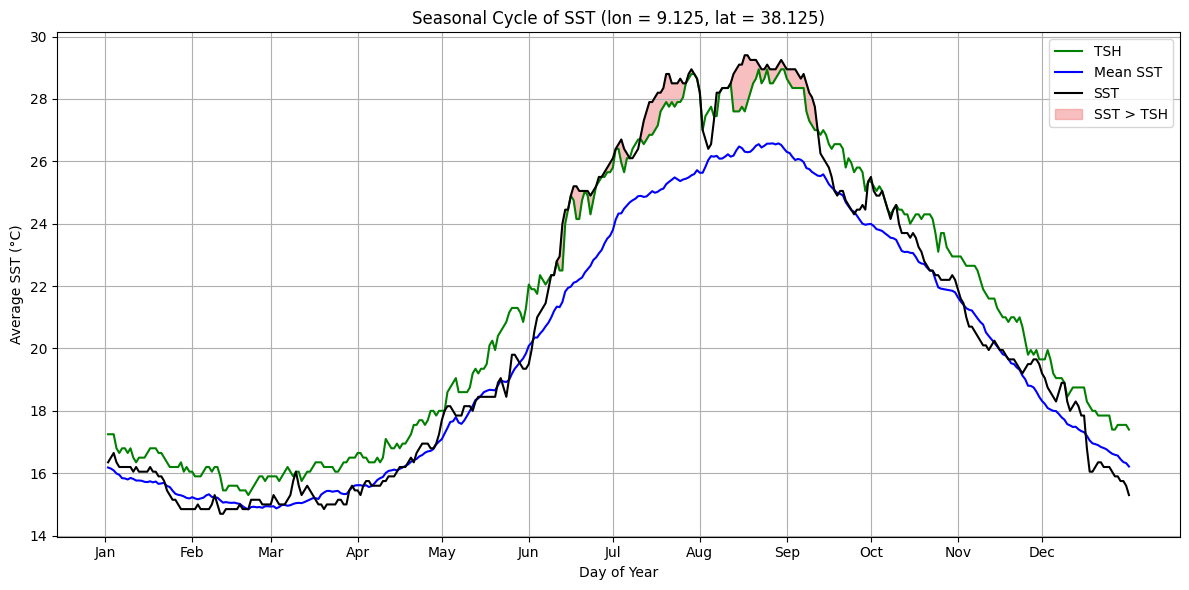

In [ ]:
seasonal_cycle_grouped = seasonal_cycle.groupby(['month', 'day'])[['tsh', 'mean_sst']].mean().reset_index()
base_data_grouped = base_data.groupby(['month', 'day'])[['sst']].mean().reset_index()

days_in_year = pd.date_range('2023-01-01', '2023-12-31')
reference_df = pd.DataFrame({'date': days_in_year})
reference_df['month'] = reference_df['date'].dt.month
reference_df['day'] = reference_df['date'].dt.day
reference_df = reference_df[['month', 'day']]

seasonal_cycle_grouped = pd.merge(reference_df, seasonal_cycle_grouped, on=['month', 'day'], how='left')
base_data_grouped = pd.merge(reference_df, base_data_grouped, on=['month', 'day'], how='left')

seasonal_cycle_grouped.fillna(method='ffill', inplace=True)
base_data_grouped.fillna(method='ffill', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(seasonal_cycle_grouped) + 1), seasonal_cycle_grouped['tsh'], 'g', label='TSH')
plt.plot(range(1, len(seasonal_cycle_grouped) + 1), seasonal_cycle_grouped['mean_sst'], 'b', label='Mean SST')
plt.plot(range(1, len(base_data_grouped) + 1), base_data_grouped['sst'], c='black', label='SST')

indices_sst_gt_tsh = base_data_grouped['sst'] > seasonal_cycle_grouped['tsh']

plt.fill_between(range(1, len(seasonal_cycle_grouped) + 1), seasonal_cycle_grouped['tsh'], base_data_grouped['sst'],
                 where=indices_sst_gt_tsh, color='lightcoral', alpha=0.5, interpolate=True, label='SST > TSH')

plt.xlabel('Day of Year')
plt.ylabel('Average SST (°C)')
plt.title('Seasonal Cycle of SST (lon = 9.125, lat = 38.125)')
plt.grid(True)

# Set x-axis ticks and labels
month_indices = []
for month in range(1, 13):
    month_indices.append(seasonal_cycle_grouped[seasonal_cycle_grouped["month"] == month].index[0])
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(month_indices, month_labels)

plt.tight_layout()
plt.legend()
plt.show()


# Visualization of the marine heatwaves
After having the results we wanted we exported them to a parquet file and read them on our own computer to continue working
## Spatial Vizualisation

In [ ]:
marine_heatwaves.drop(columns=["start_date", "end_date"]).to_parquet("marine_heatwaves.parquet")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
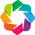

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import folium
from folium.plugins import HeatMap
from branca.colormap import LinearColormap
import holoviews as hv
from holoviews import opts
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from gsw import distance
hv.extension('bokeh')

In [2]:
df = pd.read_parquet("marine_heatwaves.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50840526 entries, 0 to 50840525
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   lat             float64
 1   lon             float64
 2   year            Int64  
 3   month           Int64  
 4   day             Int64  
 5   sst             float64
 6   tsh             float64
 7   group_id        Int64  
 8   event_duration  Int64  
 9   intensite       float64
dtypes: Int64(5), float64(5)
memory usage: 4.0 GB


In [3]:

def optimize_dataframe(df):
    """
    Optimise le DataFrame pour réduire l'utilisation mémoire
    """
    df['year'] = df['year'].astype('int16')
    df['month'] = df['month'].astype('int8')
    df['day'] = df['day'].astype('int8')
    df['group_id'] = df['group_id'].astype('int32')
    df['event_duration'] = df['event_duration'].astype('int16')

    df['lat'] = df['lat'].astype('float32')
    df['lon'] = df['lon'].astype('float32')
    df['sst'] = df['sst'].astype('float32')
    df['tsh'] = df['tsh'].astype('float32')
    df['intensite'] = df['intensite'].astype('float32')
    
    return df


In [4]:
def aggregate_data(df, resolution=1.0):
    """
    Agrège les données sur une grille pour réduire le volume
    """
    df_temp = df.copy()
    
    df_temp['lat_bin'] = np.round(df_temp['lat'] / resolution) * resolution
    df_temp['lon_bin'] = np.round(df_temp['lon'] / resolution) * resolution
    
    agg_df = df_temp.groupby(['lat_bin', 'lon_bin', 'year', 'month']).agg({
        'intensite': 'mean',
        'event_duration': 'max',
        'group_id': 'count'
    }).reset_index()
    
    return agg_df

In [5]:
def create_static_map(df, year, month, use_bins=True):
    """
    Crée une carte statique pour une période donnée
    """
    mask = (df['year'] == year) & (df['month'] == month)
    period_data = df[mask].copy()
    
    lat_col = 'lat_bin' if use_bins else 'lat'
    lon_col = 'lon_bin' if use_bins else 'lon'
    
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    
    ax.set_global()
    
    if len(period_data) > 0:
        scatter = ax.scatter(period_data[lon_col], 
                           period_data[lat_col],
                           c=period_data['intensite'],
                           cmap='YlOrRd',
                           s=50,
                           alpha=0.6,
                           transform=ccrs.PlateCarree())
        
        plt.colorbar(scatter, label='Intensité', orientation='horizontal', pad=0.05)
    else:
        print(f"Aucune donnée disponible pour {year}/{month}")
    
    plt.title(f'Vagues de chaleur marines - {year}/{month:02d}')
    
    return fig


In [6]:
def create_interactive_map(df, year, month, use_bins=True):
    """
    Crée une carte interactive avec Folium pour une période donnée
    """
    lat_col = 'lat_bin' if use_bins else 'lat'
    lon_col = 'lon_bin' if use_bins else 'lon'
    
    mask = (df['year'] == year) & (df['month'] == month)
    period_data = df[mask]
    
    m = folium.Map(location=[0, 0], zoom_start=2,
                  tiles='CartoDB positron')
    
    heat_data = [[row[lat_col], row[lon_col], row['intensite']] 
                 for idx, row in period_data.iterrows()]
    
    colormap = LinearColormap(
        colors=['yellow', 'orange', 'red'],
        vmin=period_data['intensite'].min(),
        vmax=period_data['intensite'].max()
    )
    
    HeatMap(heat_data, 
            radius=8,  # Taille des points
            blur=10,  # Lissage
            max_zoom=13,
            gradient=colormap,
            min_opacity=0.5
           ).add_to(m)
    
    colormap.add_to(m)
    colormap.caption = 'Intensité des vagues de chaleur'
    
    title_html = f'''
        <h3 align="center" style="font-size:16px">
            <b>Vagues de chaleur marines - {year}/{month:02d}</b>
        </h3>
    '''
    m.get_root().html.add_child(folium.Element(title_html))
    
    return m


In [7]:
df_agg = aggregate_data(df, resolution=1.0)


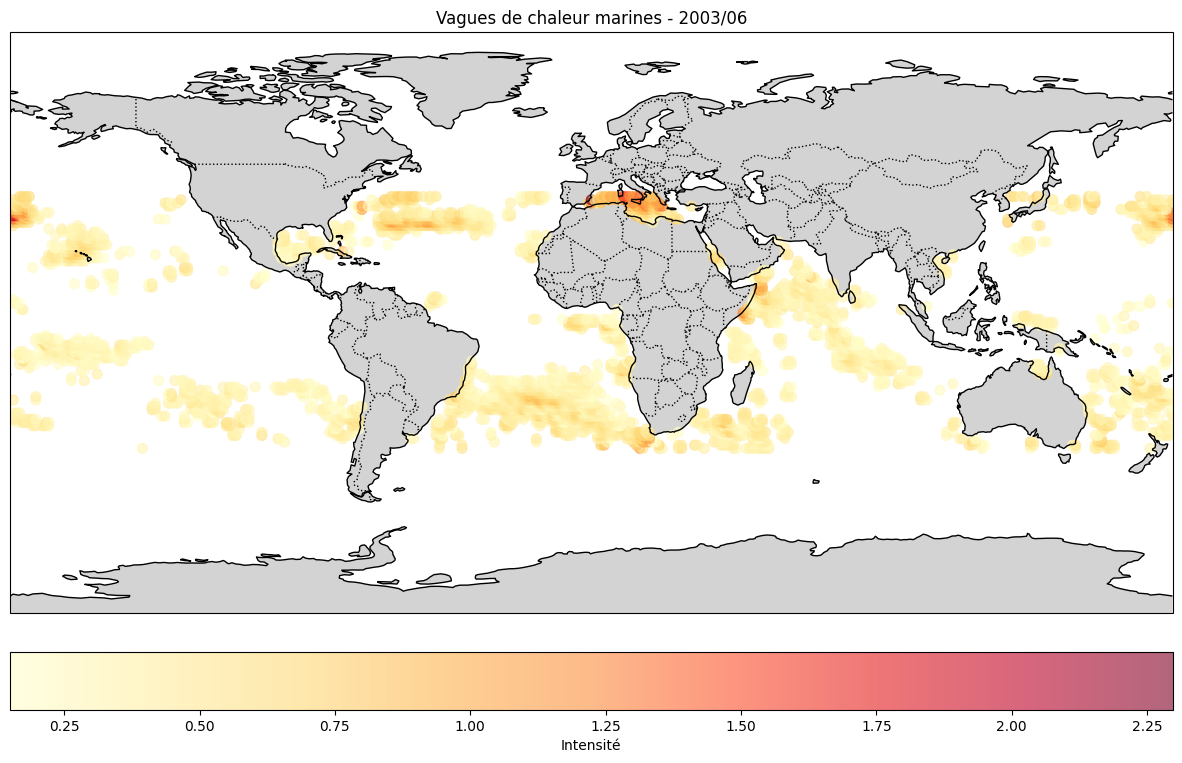

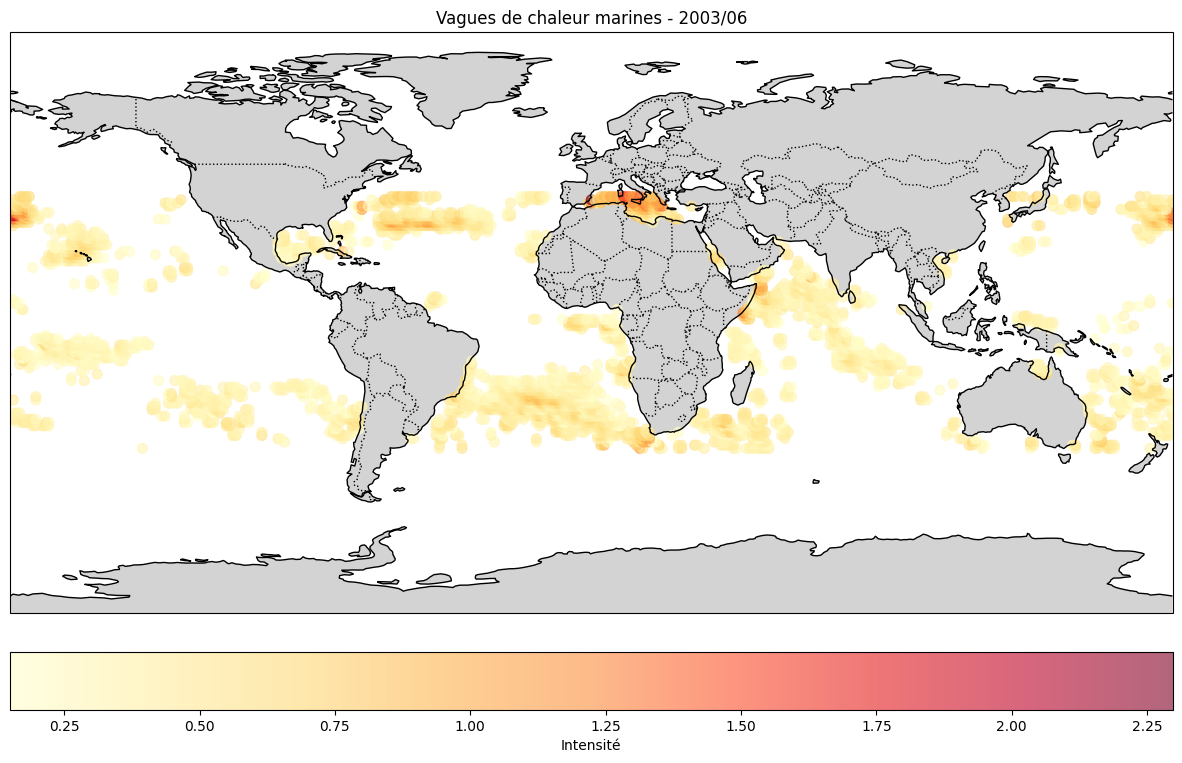

In [8]:
create_static_map(df_agg, 2003, 6)

In [ ]:
opti_df = optimize_dataframe(df)
agg_df = aggregate_data(df)

In [18]:
def create_heatwave_map(df, zone, month=8, year=2003, lat_min=30, lat_max=46, lon_min=-5, lon_max=36):
    """
    Crée une carte des vagues de chaleur
    """
    med_bounds = {
        'lat_min': lat_min,
        'lat_max': lat_max,
        'lon_min': lon_min,
        'lon_max': lon_max
    }
    
    mask = (
        (df['year'] == year) &
        (df['month'] == month) &
        (df['lat'].between(med_bounds['lat_min'], med_bounds['lat_max'])) &
        (df['lon'].between(med_bounds['lon_min'], med_bounds['lon_max']))
    )
    med_data = df[mask].copy()
    
    event_stats = med_data.groupby('group_id').agg({
        'lat': 'mean',
        'lon': 'mean',
        'intensite': 'mean',
        'event_duration': 'max',
        'day': 'min'  # jour de début de l'événement
    }).reset_index()
    
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Configurer la carte
    ax.set_extent([med_bounds['lon_min'], med_bounds['lon_max'],
                  med_bounds['lat_min'], med_bounds['lat_max']])
    
    # Ajouter les éléments de la carte
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    
    # Ajouter une grille
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    # Créer le scatter plot
    scatter = ax.scatter(event_stats['lon'],
                        event_stats['lat'],
                        c=event_stats['intensite'],
                        s=event_stats['event_duration'] * 20,  # Taille proportionnelle à la durée
                        cmap='YlOrRd',
                        alpha=0.6,
                        transform=ccrs.PlateCarree())
    
    # Ajouter les barres de couleur
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label('Average Intensity of heatwaves in °C')
    
    # Ajouter une légende pour la taille des points
    legend_elements = [
        plt.scatter([], [], s=20*d, c='gray', alpha=0.6, label=f'{d} jours')
        for d in [5, 10, 20, 30]
    ]
    ax.legend(handles=legend_elements, title='Duration of event ',
             loc='upper left', bbox_to_anchor=(0.02, 0.98))
    
    # Ajouter un titre
    plt.title(f'Marine Heatwaves in {zone} - {month:02}/{year}\n'
              f'Number of events: {len(event_stats)}', pad=20)
    analyze_events(med_data)
    return fig, med_data

def analyze_events(med_data):
    """
    Retourne des statistiques sur les événements
    """
    
    event_stats = med_data.groupby('group_id').agg({
        'intensite': ['mean', 'max'],
        'event_duration': 'max',
        'day': 'min'
    }).round(2)
    
    stats_summary = {
        'total_events': len(event_stats),
        'avg_duration': event_stats['event_duration']['max'].mean(),
        'max_duration': event_stats['event_duration']['max'].max(),
        'avg_intensity': event_stats['intensite']['mean'].mean(),
        'max_intensity': event_stats['intensite']['max'].max()
    }
    
    return stats_summary, event_stats

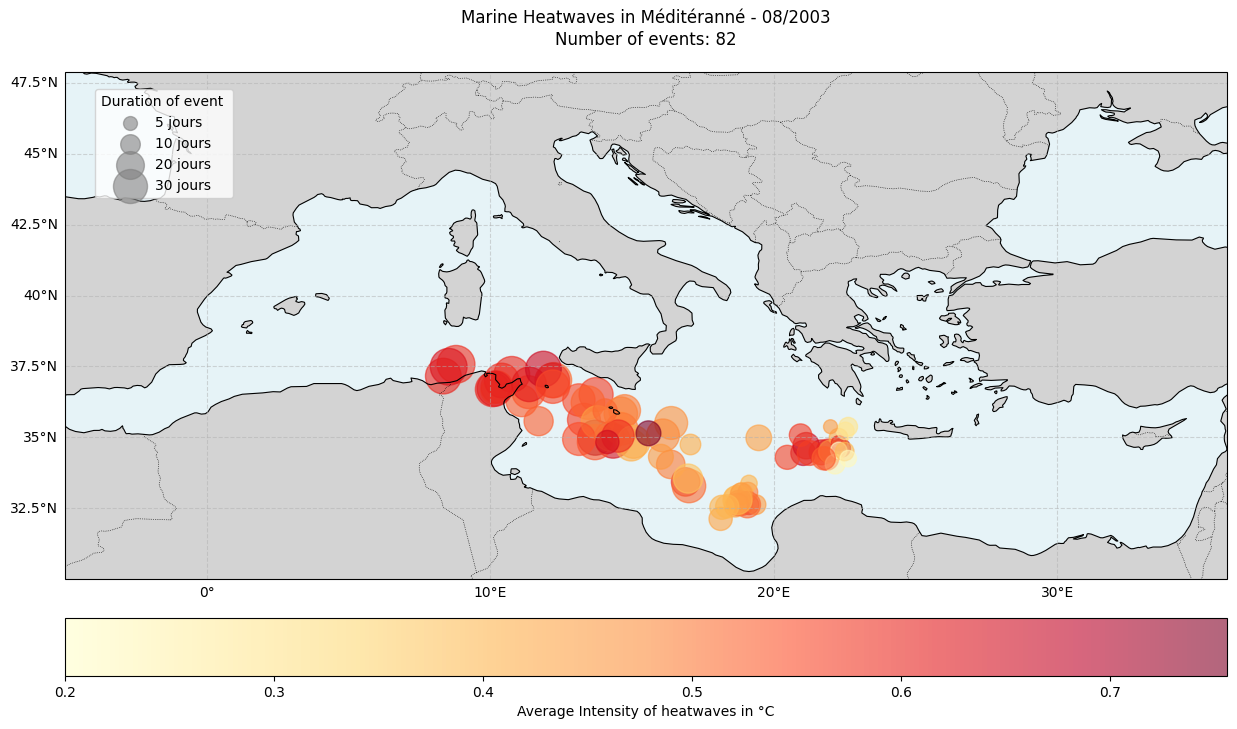


Statistiques des vagues de chaleur en West Aust - Feb 2011:
total_events: 82.00
avg_duration: 20.01
max_duration: 37.00
avg_intensity: 0.51
max_intensity: 3.75


In [10]:

fig, med_data = create_heatwave_map(df,"Méditéranné")
plt.show()

summary, events = analyze_events(med_data)
print("\nStatistiques des vagues de chaleur en West Aust - Feb 2011:")
for key, value in summary.items():
    print(f"{key}: {value:.2f}")

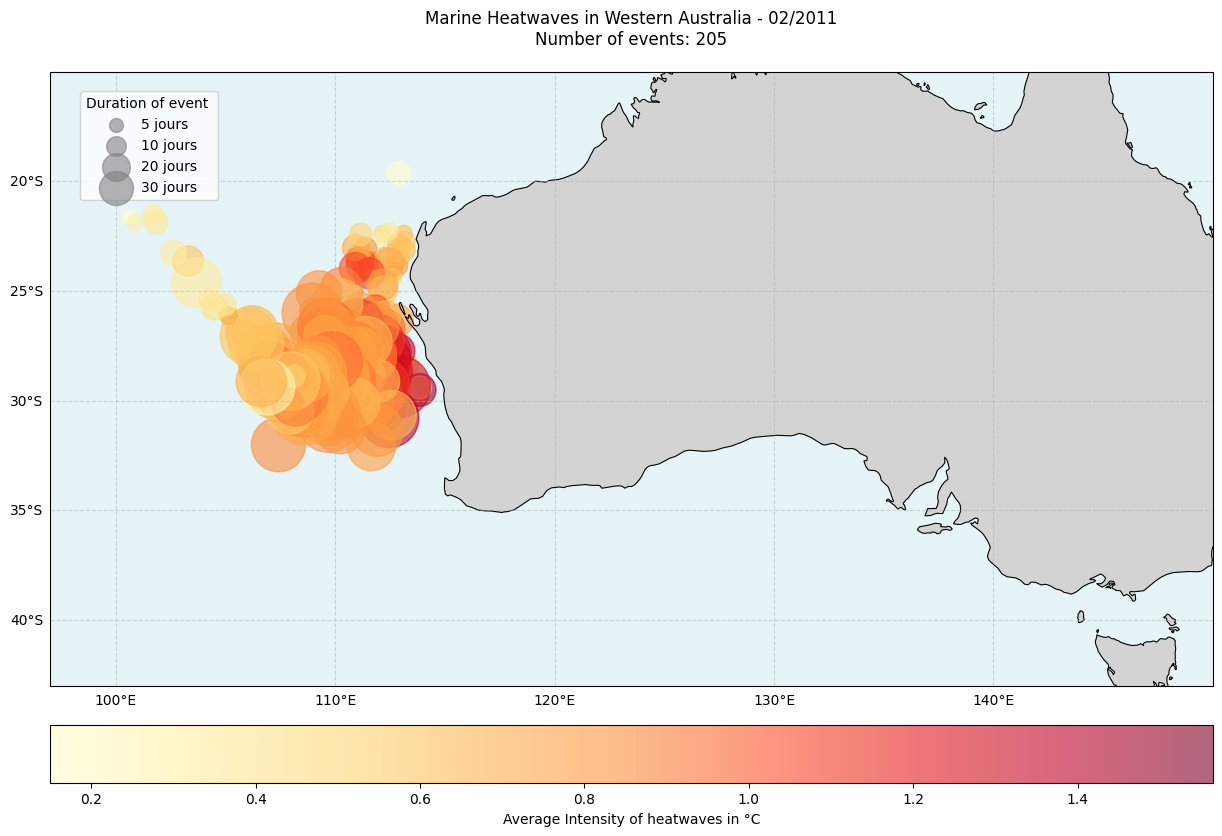


Statistiques des vagues de chaleur en West Aust - Feb 2011:
total_events: 205.00
avg_duration: 53.48
max_duration: 127.00
avg_intensity: 0.82
max_intensity: 4.20


In [11]:

fig, med_data = create_heatwave_map(df, "Western Australia", month=2, year=2011, lat_min=-40, lat_max=-15, lon_min=97, lon_max=150)
plt.show()

summary, events = analyze_events(med_data)
print("\nStatistiques des vagues de chaleur en West Aust - Feb 2011:")
for key, value in summary.items():
    print(f"{key}: {value:.2f}")

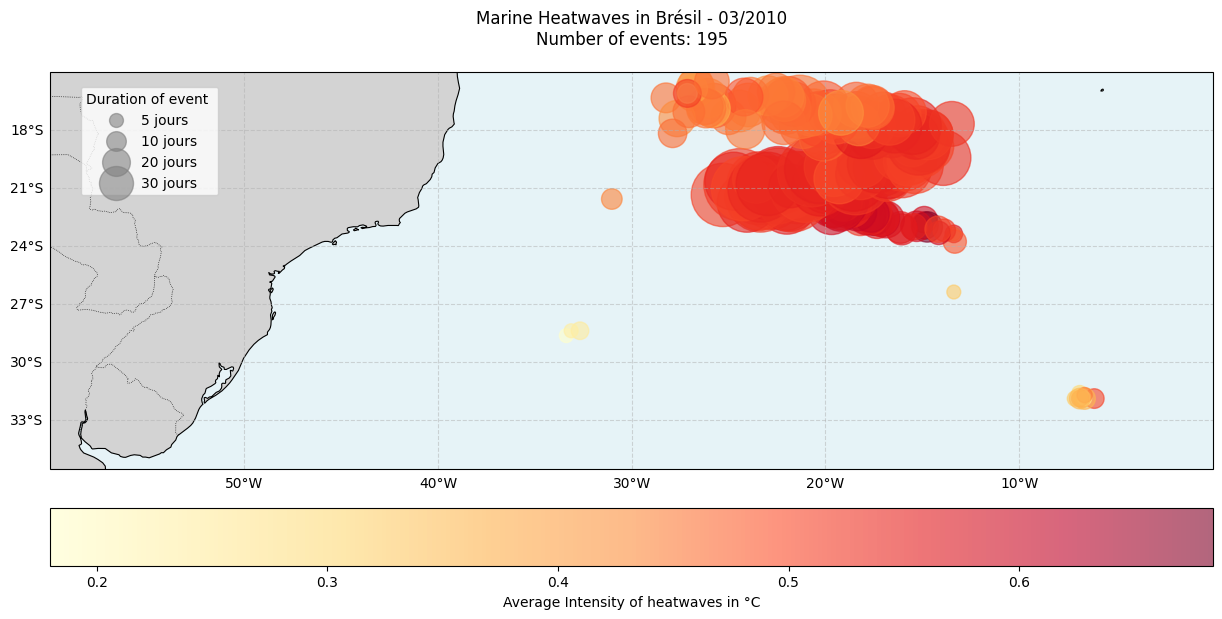


Statistiques des vagues de chaleur en Brésil - Mars 2010:
total_events: 4515.00
avg_duration: 71.86
max_duration: 355.00
avg_intensity: 0.54
max_intensity: 7.20


In [12]:
fig = create_heatwave_map(df, "Brésil", month=3, year=2010, lat_min=-32, lat_max=-15, lon_min=300, lon_max=360)
plt.show()

summary, events = analyze_events(df)
print("\nStatistiques des vagues de chaleur en Brésil - Mars 2010:")
for key, value in summary.items():
    print(f"{key}: {value:.2f}")

In [13]:

def create_animation(df, output_path='heatwave_animation.gif', use_bins=True, interval=200):
    """
    Crée une animation montrant l'évolution temporelle des vagues de chaleur
    """
    
    lat_col = 'lat_bin' if use_bins else 'lat'
    lon_col = 'lon_bin' if use_bins else 'lon'
    
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    def update(frame):
        ax.clear()
        
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.OCEAN, facecolor='white')
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.gridlines()
        ax.set_global()
        
        year = 2003 + frame // 12
        month = 1 + frame % 12
        
        mask = (df['year'] == year) & (df['month'] == month)
        period_data = df[mask]
        
        if len(period_data) > 0:
            scatter = ax.scatter(period_data[lon_col],
                            period_data[lat_col],
                            c=period_data['intensite'],
                            cmap='YlOrRd',
                            s=50,
                            alpha=0.6,
                            transform=ccrs.PlateCarree(),
                            label='Heatwave')
            if not hasattr(fig, 'colorbar'):
                fig.colorbar = plt.colorbar(scatter, 
                                          label='Heatwave Intensity in °C', 
                                          orientation='horizontal',
                                          pad=0.05,
                                          shrink=0.8)
        ax.set_title(f"Marine Heatwaves - {year}/{month:02d}")

        
        return ax

    n_frames = (2015 - 2003 + 1) * 12  # Nombre total de mois
    
    anim = FuncAnimation(fig, 
                        update, 
                        frames=n_frames,
                        interval=interval,
                        blit=False)
    
    writer = PillowWriter(fps=1000//interval,  # fps basé sur l'intervalle
                         metadata=dict(artist='Marine Heatwave Visualization'),
                         bitrate=2000)
    
    print(f"Création de l'animation... Cela peut prendre quelques minutes.")
    anim.save(output_path, writer=writer)
    print(f"Animation sauvegardée dans {output_path}")
    
    return anim


In [ ]:
def calculate_pixel_size(lat, lon):
    """
    Fonction pour calculer la taille de chaque pixel, (éxécution trop longue)
    """

    lat_north = lat + 0.125
    lat_south = lat - 0.125

    lon_east = lon + 0.125
    lon_west = lon - 0.125

    dist_ns = distance([lon, lon], [lat_south, lat_north])[0]  # [m]

    dist_ew = distance([lon_west, lon_east], [lat, lat])[0]  # [m]

    return dist_ns * dist_ew

df["pixel_size_m2"] = df.apply(lambda row: calculate_pixel_size(row["lat"], row["lon"]), axis=1)


Création de l'animation... Cela peut prendre quelques minutes.
Animation sauvegardée dans mhw.gif


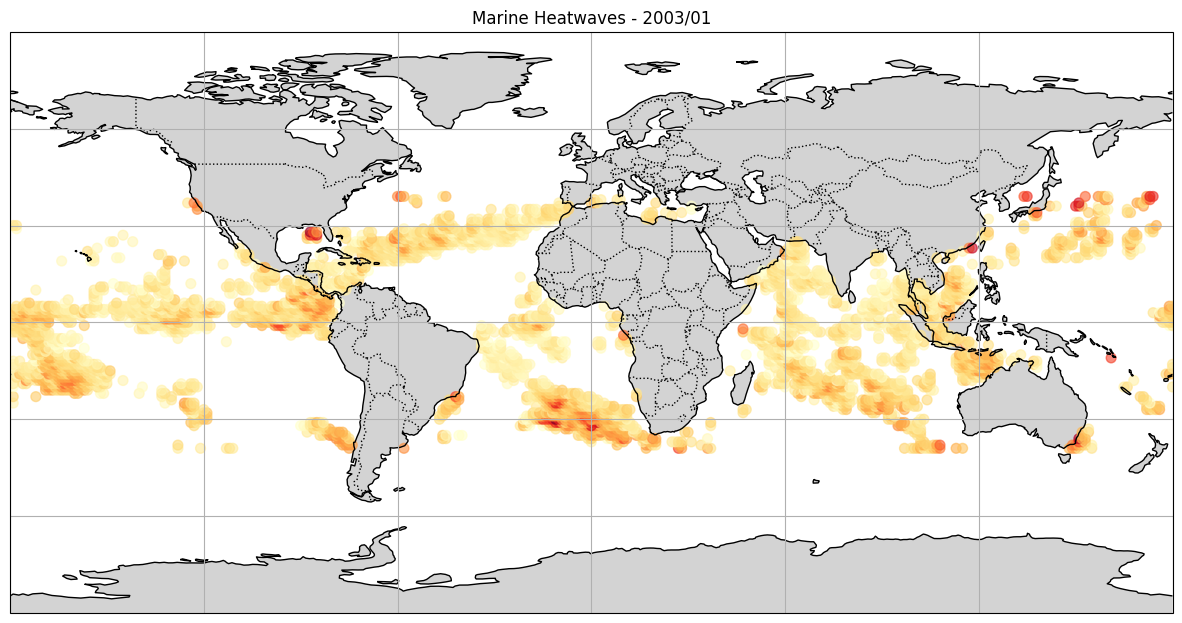

In [15]:
create_animation(df_agg, 'mhw.gif')

## Temporal vizualisation

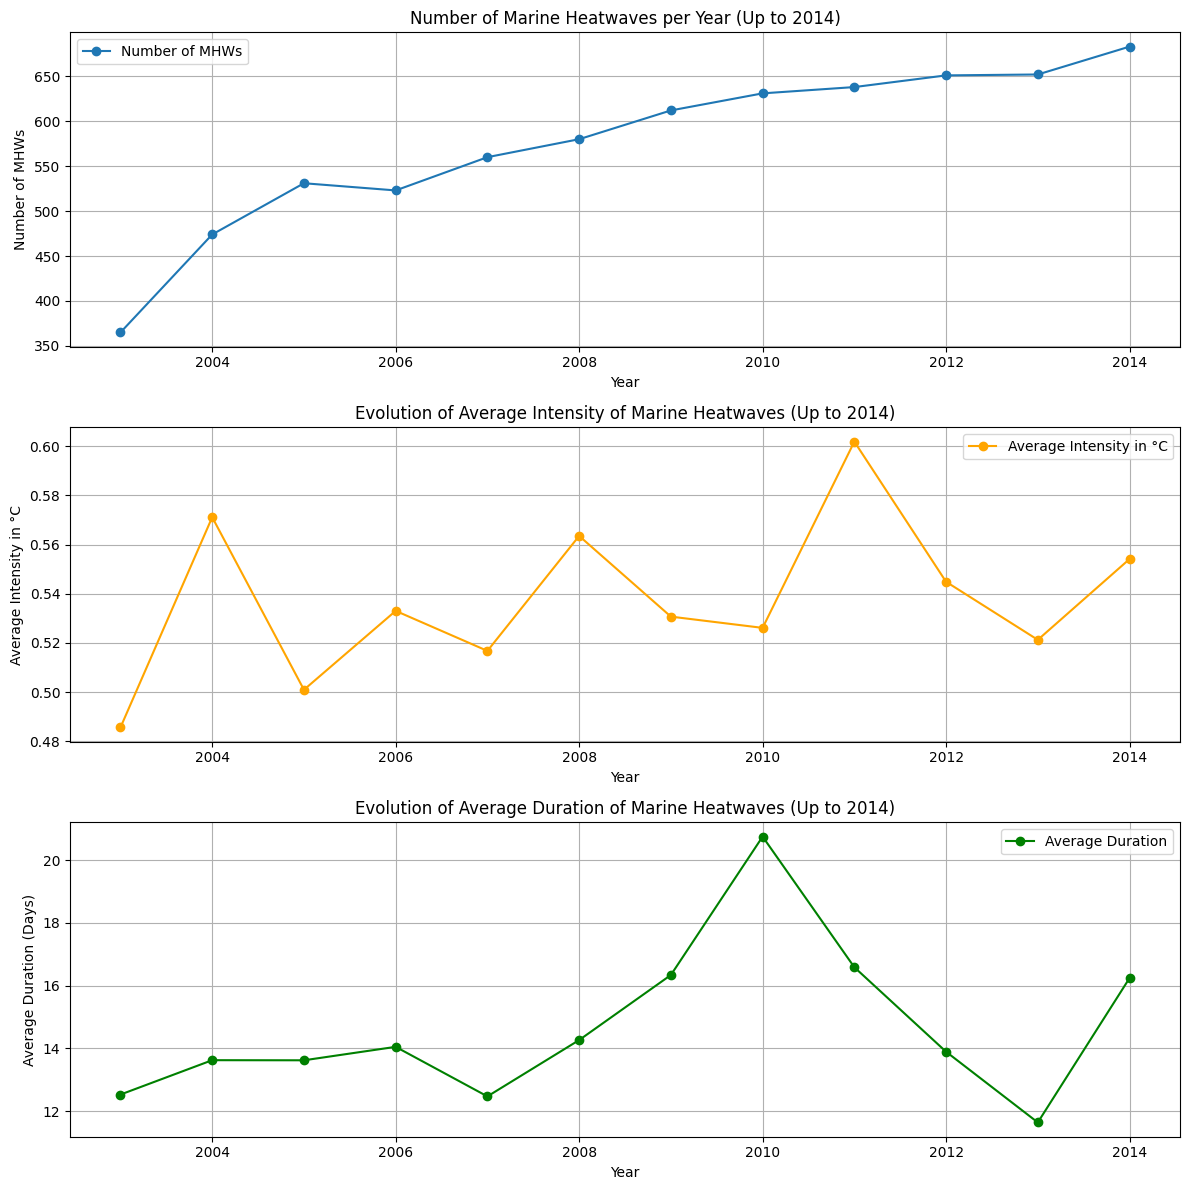

In [ ]:
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)

df_filtered = df[df['year'] <= 2014]

mhw_count_by_year = df_filtered.groupby('year')['group_id'].nunique()

mean_intensity_by_year = df_filtered.groupby('year')['intensite'].mean()

mean_duration_by_year = df_filtered.groupby('year')['event_duration'].mean()

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1)
plt.plot(mhw_count_by_year.index, mhw_count_by_year.values, marker='o', label='Number of MHWs')
plt.title("Number of Marine Heatwaves per Year (Up to 2014)")
plt.xlabel("Year")
plt.ylabel("Number of MHWs")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(mean_intensity_by_year.index, mean_intensity_by_year.values, marker='o', color='orange', label='Average Intensity in °C')
plt.title("Evolution of Average Intensity of Marine Heatwaves (Up to 2014)")
plt.xlabel("Year")
plt.ylabel("Average Intensity in °C")
plt.grid(True)
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(mean_duration_by_year.index, mean_duration_by_year.values, marker='o', color='green', label='Average Duration')
plt.title("Evolution of Average Duration of Marine Heatwaves (Up to 2014)")
plt.xlabel("Year")
plt.ylabel("Average Duration (Days)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()